### 网络结构
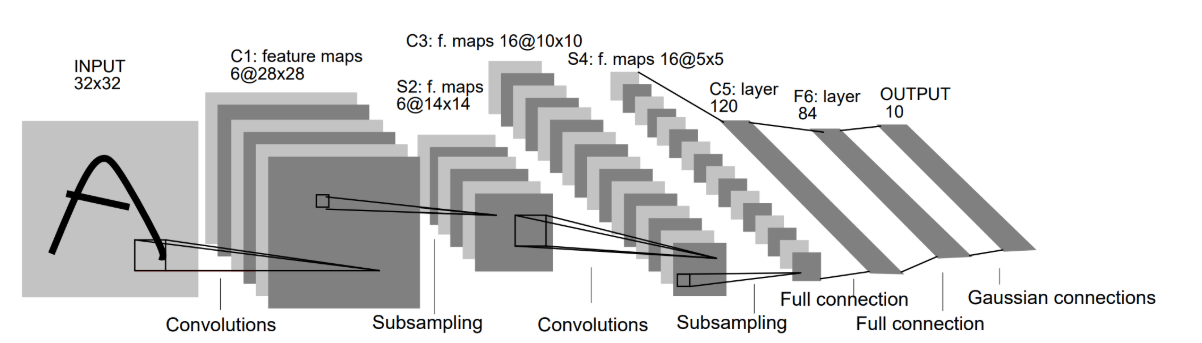

### 定义模型

In [ ]:
import torch
import torch.nn as nn


class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # C1
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool1 = nn.AvgPool2d(2, stride=2)
        # C2
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(2, stride=2)
        # C3
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        # F4
        self.fc1 = nn.Linear(120, 84)
        # F5
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = nn.functional.tanh(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = nn.functional.tanh(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = nn.functional.tanh(x)
        x = x.view(-1, 120)
        x = self.fc1(x)
        x = nn.functional.tanh(x)
        x = self.fc2(x)
        return x

### 测试模型构建

In [2]:
x = torch.randn(4, 1, 32, 32)
model = LeNet(num_classes=10)
output = model(x)
print(output.shape)  # Expected output shape: (4, 10)

torch.Size([4, 10])
